<a href="https://colab.research.google.com/github/p-garden/p-garden/blob/main/%EB%B0%95%EC%A0%95%EC%9B%90_9week_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **문제 1**

## 문제내용

다음 문제가 옳은지 틀린지 답하고 틀렸다면 옳게 고쳐주세요!

1. 풀링을 사용하는 이유는 합성곱에서 스트라이드를 크게 하여 특성 맵을 줄이는 것보다 풀링 층에서 크기를 줄이는 것이 경험적으로 더 나은 성능을 내기 때문이다.

2. 풀링할 때 stride의 크기와 풀링의 결과의 크기는 비례한다.

3. 커널 배열의 깊이와 입력의 깊이는 관련이 없다.

4. 패딩의 종류에는 same과 valid가 존재하고 둘 다 특성 맵의 크기가 줄어드는걸 막아줍니다.

5. Model 클래스는 Sequential 클래스처럼 자동으로 InputLayer 클래스를 추가해줍니다.

6. a 라는 [30,30,1]의 크기를 가지는 3차원 배열이 있다. model=keras.Sequntial()인 객체를 훈련시키고 model을 통해 a라는 배열의 0번째 이미지에 대한 예측 확률을 알고 싶다고 한다. 이 때, print(model.predict(a[0]))를 이용하면 알 수 있다.

1. O
2. X / stride의 크기는 풀링 영역이 이동하는 크기와 같다.
3. X / 커넣의 깊이와 입력층의 깊이는 같아야 한다.
4. X / same padding만이 특성 맵의 크기가 줄어드는 것을 막아준다.
5. O
6.X / a[0:1]의 슬라이싱 연산자 사용 

# **문제 2**

## 문제내용

2-1. 합성곱 연산과 풀링 연산의 차이점에 대해서 설명해보세요

2-2. 합성곱층에서 출력된 9x9 특성맵이 아래와 같다. (stride는 default값이다. 즉 stride=1)

| 48 | 5 | 23 | 33 | 90 | 51 | 13 | 44 | 47 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 15 | 24 | 61 | 66 | 70 | 80 | 69 | 43 | 18 |
| 36 | 53 | 87 | 11 | 76 | 34 | 59 | 99 | 38 |
| 94 | 17 | 10 | 27 | 28 | 56 | 58 | 62 | 20 |
| 19 | 83 | 55 | 41 | 91 | 95 | 68 | 25 | 75 |
| 2 | 46 | 77 | 26 | 50 | 42 | 8 | 84 | 67 |
| 96 | 21 | 35 | 64 | 6 | 9 | 79 | 89 | 7 |
| 32 | 22 | 81 | 29 | 45 | 40 | 73 | 85 | 63 |
| 39 | 14 | 78 | 52 | 71 | 72 | 98 | 16 | 60 |

(3,3) 최대 폴링으로 적용되었을 때 결과를 출력 하라

2-1 
합성곱층은 입력의 크기를 유지하며 특성맵을 출력
풀링층은 특성맵의 크기를 줄여서 출력

2-2

87 90 99

94 95 84

96 72 98

# **문제 3. Pooling의 힘을 느껴보자**

[]

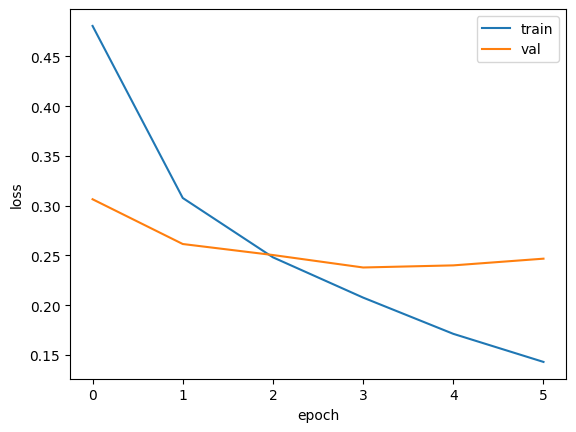

In [3]:
from tensorflow import keras
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()
train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0
train_scaled, val_scaled, train_target, val_target = train_test_split(train_scaled, train_target, test_size = 0.2, random_state = 42)


model = keras.Sequential()
# 첫 번째 합성곱 층 Conov2D / 32개 필터, 커널 size = 3, activation = 'relu', padding = 'valid'
model.add(keras.layers.Conv2D(32,kernel_size=3, activation='relu', padding='valid', input_shape=(28,28,1)))

# 두 번째 합성곱 층 Conov2D / 64개 필터, 커널 size = 3, activation = 'relu', padding = 'valid'
model.add(keras.layers.Conv2D(64,kernel_size=3, activation='relu', padding='valid'))


# Flatten / dense 은닉층 / dropout을 자유롭게 사용해서 마지막 출력층전의 신경망을 구성해봅시다.
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dropout(0.4))

model.add(keras.layers.Dense(10, activation = 'softmax'))


# 모델 훈련
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = 'accuracy')
early_stopping_cb = keras.callbacks.EarlyStopping(patience = 2, restore_best_weights= True)
history = model.fit(train_scaled, train_target, epochs = 20, verbose = 0, validation_data = (val_scaled, val_target), callbacks = early_stopping_cb)


# 그래프 그리기

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])

plt.plot()



[]

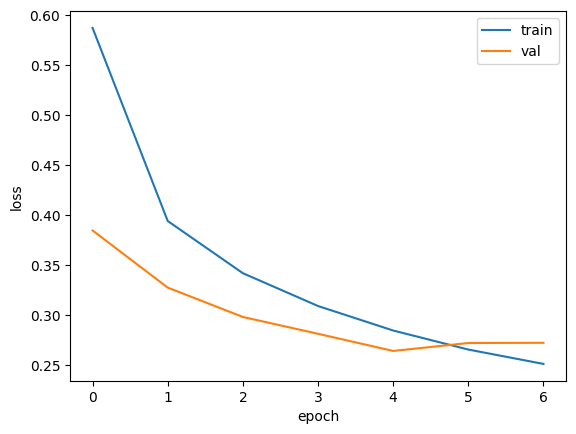

In [4]:
model = keras.Sequential()
# 합성곱 신경망 구성
model.add(keras.layers.Conv2D(32,kernel_size=3, activation='relu', padding='valid', input_shape=(28,28,1)))
model.add(keras.layers.MaxPooling2D(2))
model.add(keras.layers.Conv2D(64,kernel_size=3, activation='relu', padding='valid'))
model.add(keras.layers.MaxPooling2D(2))

model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dropout(0.4))

model.add(keras.layers.Dense(10, activation = 'softmax'))


#모델 훈련
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = 'accuracy')
early_stopping_cb = keras.callbacks.EarlyStopping(patience = 2, restore_best_weights= True)
history = model.fit(train_scaled, train_target, epochs = 20, verbose = 0, validation_data = (val_scaled, val_target), callbacks = early_stopping_cb)

# 그래프 그리기

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])

plt.plot()


# **문제 4**

CIFAR dataset

(50000, 32, 32, 3)
AxesImage(size=(32, 32))
Model: "sequential_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_26 (Conv2D)          (None, 32, 32, 32)        896       
                                                                 
 max_pooling2d_14 (MaxPoolin  (None, 16, 16, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_27 (Conv2D)          (None, 14, 14, 64)        18496     
                                                                 
 max_pooling2d_15 (MaxPoolin  (None, 7, 7, 64)         0         
 g2D)                                                            
                                                                 
 conv2d_28 (Conv2D)          (None, 5, 5, 64)          36928     
                                                                 
 flatten_

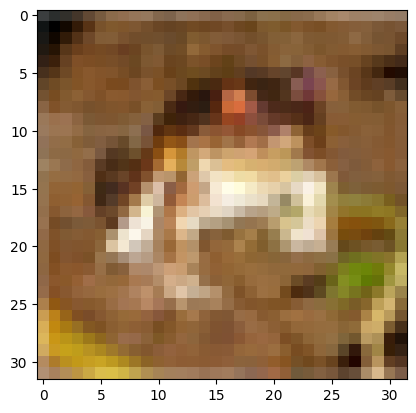

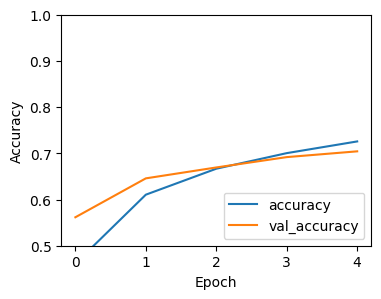

In [10]:
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Activation, Dropout

from tensorflow.keras.callbacks import Callback, EarlyStopping



(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

#train_images의 shape를 출력.
print(train_images.shape)

#0과 1사이의 값으로 변환.
train_images, test_images = train_images / 255.0, test_images / 255.0



#첫번째 train_image를 출력.
print(plt.imshow(train_images[0]))
##합성 신경망을 구현해보자.
model = models.Sequential()



###CIFAR 이미지 형식인 형상(32, 32, 3)의 입력을 처리하도록 CNN을 구성할것.
### 32개의 필터, 커널 사이즈가 (3,3)임
###활성함수는 relu임
###세임 패딩을 이용.
model.add(layers.Conv2D(32,kernel_size=(3,3),activation='relu', padding='same',input_shape=(32,32,3) ))


###최대풀링으로 (2,2)로 설정.
model.add(layers.MaxPooling2D(2,2))
### 64개의 필터, 커널 사이즈가 (3,3)임
###활성함수는 relu임
model.add(layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
###최대풀링으로 (2,2)로 설정.

model.add(layers.MaxPooling2D(2,2))

### 64개의 필터, 커널 사이즈가 (3,3)임

###활성함수는 relu임
model.add(layers.Conv2D(64,kernel_size=(3,3), activation='relu'))
model.add(layers.Flatten())
### 3D 출력을 1D로 펼쳤음.. 그다음 Dense층을 추가함.
### MNIST 데이터는 10개의 클래스가 있으므로 마지막에 Dense 층에 10개의 출력과 소프트맥스 활성화 함수를 사용.
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))
model.summary()
##컴파일 후 학습을 시켜보자.
###adam으로 최적화하고, 정확도가 척도임.
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=8, restore_best_weights = True)
###model을 훈련.
###train_images,train_labels를 이용,
###epochs=5 epochs를 10번 이상을 두면 좋지만 실행시간이 현저히 오래 걸림->epochs=10으로도 해볼것.
###callback으로 early_stop을 받음.
###검증 데이터로 테스트를 넣음
history = model.fit(train_images, train_labels, epochs=5, validation_data=(test_images, test_labels), callbacks=[early_stop])

plt.figure(figsize=(4,3))
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])

plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
                  

# **문제 5**

 MNIST dataset

In [55]:
from tensorflow import keras
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# MNIST dataset 를 불러온다
(train_input, train_target), (test_input, test_target) = keras.datasets.mnist.load_data()

# 샘플 데이터 개수 출력
print(f"{train_input.shape[0]} train samples")
print(f"{test_input.shape[0]} test samples")

60000 train samples
10000 test samples


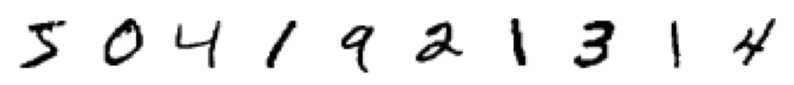

In [56]:
"""
문제 0.
훈련 데이터에서 10개의 샘플을 출력해보자
"""

fig,axs = plt.subplots(1,10,figsize=(10,10))
for i in range(10):
  axs[i].imshow(train_input[i], cmap='gray_r')  
  axs[i].axis('off')


In [57]:
"""
문제 1.
MNIST data preprocessing
- Conv2D를 사용하기 위해 채널 차원을 추가해야 함
- 0 ~ 255인 datascale을 0 ~ 1로 전처리
- train set에서 검증 세트 분리하기
"""
train_scaled = train_input.reshape(-1,28,28,1) / 255.0
train_scaled, val_scaled, train_target, val_target = train_test_split(train_scaled, train_target, random_state=42)

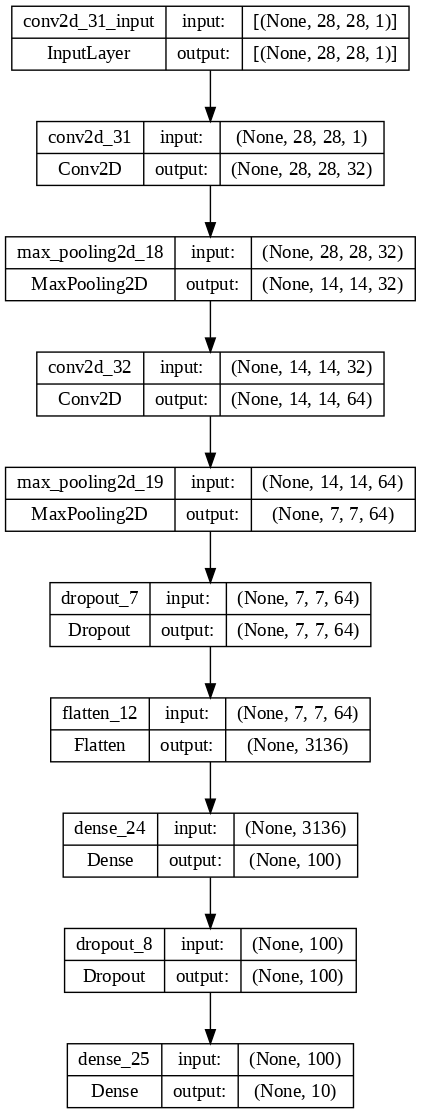

In [58]:
"""
문제 2.
CNN 만들기 (구조를 지키되, 나머지 하이퍼파라미터는 자유롭게 조정)
- Conv2D
- MaxPooling
- Conv2D
- MaxPooling
- Dropout
- Flatten
- Dense
- Dropout
- Dense - activation:softmax
"""
model = keras.Sequential()
model.add(keras.layers.Conv2D(32,kernel_size=3, activation='relu', padding='same', input_shape=(28,28,1)))
model.add(keras.layers.MaxPooling2D(2))
model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu', padding='same'))
model.add(keras.layers.MaxPooling2D(2))
model.add(keras.layers.Dropout(0.4))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100,activation='relu'))
model.add(keras.layers.Dropout(0.4))
model.add(keras.layers.Dense(10,activation='softmax'))

"""
여기에 코드 작성
"""

keras.utils.plot_model(model, show_shapes=True, to_file='cnn-architecture.png', dpi=100)

In [59]:
model. compile(optimizer='adam',loss='sparse_categorical_crossentropy', metrics='accuracy')
checkpoint_cb1 = ModelCheckpoint('earlystopping.h5', save_best_only=True)
checkpoint_cb2 = ModelCheckpoint('non-earlystopping.h5', save_best_only=True)
earlystopping_cb = EarlyStopping(patience=2, restore_best_weights=True)

"""
문제 3.
model.fit() - epochs = 20, validation_data, callbacks
history1에는 조기 종료를 적용
history2에는 조기 종료 미적용
"""
history1 = model.fit(train_scaled, train_target, epochs=20, validation_data=(val_scaled, val_target), callbacks=[checkpoint_cb1,earlystopping_cb])
history2 = model.fit(train_scaled, train_target, epochs=20, validation_data=(val_scaled, val_target), callbacks=[checkpoint_cb2])


"""
여기에 코드 작성
"""


Epoch 1/20
1407/1407 [==============================] - 11s 6ms/step - loss: 0.2398 - accuracy: 0.9252 - val_loss: 0.0644 - val_accuracy: 0.9811
Epoch 2/20
1407/1407 [==============================] - 9s 6ms/step - loss: 0.0954 - accuracy: 0.9709 - val_loss: 0.0468 - val_accuracy: 0.9866
Epoch 3/20
1407/1407 [==============================] - 7s 5ms/step - loss: 0.0729 - accuracy: 0.9779 - val_loss: 0.0426 - val_accuracy: 0.9873
Epoch 4/20
1407/1407 [==============================] - 8s 6ms/step - loss: 0.0646 - accuracy: 0.9811 - val_loss: 0.0387 - val_accuracy: 0.9887
Epoch 5/20
1407/1407 [==============================] - 9s 6ms/step - loss: 0.0541 - accuracy: 0.9839 - val_loss: 0.0354 - val_accuracy: 0.9903
Epoch 6/20
1407/1407 [==============================] - 12s 9ms/step - loss: 0.0493 - accuracy: 0.9848 - val_loss: 0.0335 - val_accuracy: 0.9906
Epoch 7/20
1407/1407 [==============================] - 11s 8ms/step - loss: 0.0450 - accuracy: 0.9855 - val_loss: 0.0337 - val_accura

'\n여기에 코드 작성\n'

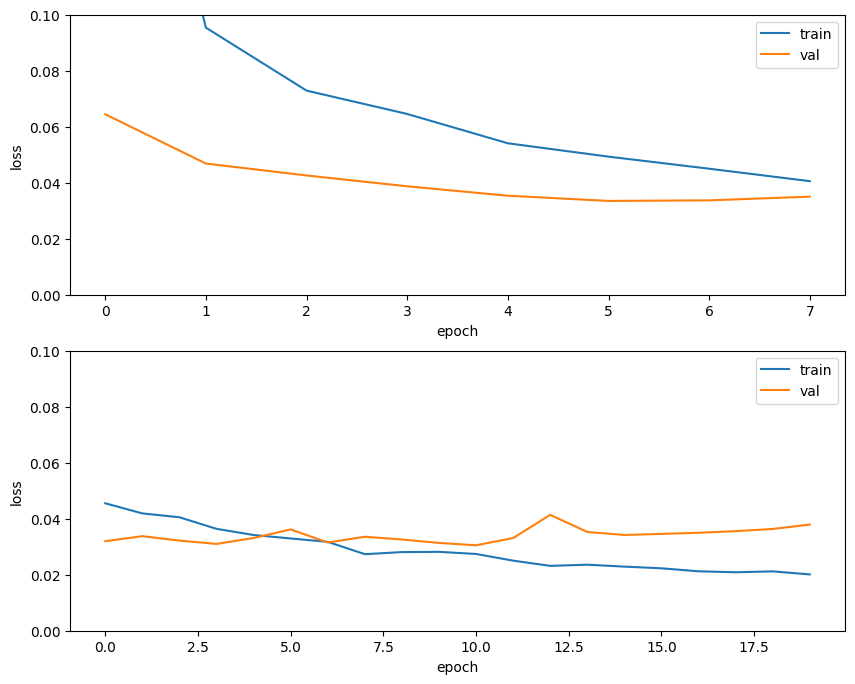

In [61]:
"""
문제 4.
history1, 2의 손실 그래프 그리기
- 두 그래프의 y축 scale을 [0, 0.1]로 통일시킨다.
"""
fig, axs = plt.subplots(2, 1, figsize=(10,8))

plt.subplot(2, 1, 1) 
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.ylim([0,0.1])

plt.subplot(2, 1, 2) 
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.ylim([0,0.1])
"""
여기에 코드 작성
"""

plt.show()




In [68]:
"""
문제 5.
history 1, history 2의 test set에 대한 성능 측정
"""
# test input preprocessing
test_scaled = test_input.reshape(-1,28,28,1) / 255.0 

"""
여기에 코드 작성
"""


# model1 evaluate (earlystopping 적용)
"""
여기에 코드 작성
"""
history1.model.evaluate(test_scaled, test_target)



313/313 [==============================] - 1s 4ms/step - loss: 0.0274 - accuracy: 0.9926


[0.027414001524448395, 0.9926000237464905]

In [69]:
# model2 evaluate (earlystopping 미적용)
"""
여기에 코드 작성
"""
history2.model.evaluate(test_scaled, test_target)

313/313 [==============================] - 1s 3ms/step - loss: 0.0274 - accuracy: 0.9926


[0.027414001524448395, 0.9926000237464905]